# Norman 2019 — Main Figure

Runs SHERLOCK (`l0_lambda=25, rank=6, synergy=True`) `N_RUNS` times on the held-out Norman split,
selects the best model by held-out combo ATE, and assembles a four-panel journal figure:

| Panel | Content |
|---|---|
| **(a)** | Counterfactual ATE across N runs — reproducibility & OOD generalisation |
| **(b)** | Single-perturbation latent UMAP (best model) |
| **(c)** | Parent-coefficient scatter (c₁ vs c₂) coloured by Norman GT class |
| **(d)** | GI classification AUC-ROC per class — SHERLOCK vs GEARS |

The notebook saves every intermediate result to `results/norman_figure/` and the final
composite figure to `results/norman_figure/main_figure.pdf`.

In [153]:
import os, sys, math, random, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler

import scanpy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import torch

sys.path.append('../../..')
import sherlock as slk
from sherlock.tools._models import classify_gi

# ── Journal figure style ────────────────────────────────────────────────
RC = {
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':             8,
    'axes.labelsize':        8,
    'axes.titlesize':        9,
    'xtick.labelsize':       7,
    'ytick.labelsize':       7,
    'legend.fontsize':       7,
    'legend.title_fontsize': 7,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.linewidth':        0.75,
    'xtick.major.width':     0.75,
    'ytick.major.width':     0.75,
    'xtick.major.size':      3,
    'ytick.major.size':      3,
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'pdf.fonttype':          42,
    'ps.fonttype':           42,
}
mpl.rcParams.update(RC)

# ── Colour palette ─────────────────────────────────────────────────────
CLR_SHERLOCK = '#2166ac'
CLR_GEARS    = '#d73027'

# Keys match the exact strings in genetic_interactions.csv
PALETTE_GI = {
    'approximately additive':         '#4DAF4A',  # green
    'epistasis':                      '#FF7F00',  # orange
    'neomorphic':                     '#984EA3',  # purple
    'potentiation':                   '#F781BF',  # pink
    'redundant':                      '#A65628',  # brown
    'suppression':                    '#E41A1C',  # red
    'synergy (dissimilar phenotype)': '#377EB8',  # blue
    'synergy (similar phenotype)':    '#6BAED6',  # light blue
}

# ── Constants ──────────────────────────────────────────────────────────
N_RUNS    = 3
SEED_BASE = 0
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT_DIR   = Path('./results/norman_figure')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}  |  N_RUNS: {N_RUNS}  |  Output: {OUT_DIR}')

Device: cuda  |  N_RUNS: 3  |  Output: results/norman_figure


## 1. Load and preprocess Norman 2019

In [154]:
data = sc.read_h5ad('../../datasets/norman/Norman_2019.h5ad')
data.X = data.layers['counts'].copy()

slk.pp.slk_prepare_data(
    data,
    pert_key='perturbation_name',
    ntc_label='control',
    treatment_key=None,
    inplace=True,
)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

all_perts    = data.obs[p_key].unique()
single_perts = [p for p in all_perts if '+' not in str(p) and p != NTC]
combo_perts  = [p for p in all_perts if '+' in str(p)]
print(f'Cells: {data.n_obs}  |  Genes: {data.n_vars}')
print(f'Single perts: {len(single_perts)}  |  Combo perts: {len(combo_perts)}')

Cells: 111255  |  Genes: 19018
Single perts: 105  |  Combo perts: 131


In [155]:
# Gene filtering: keep genes with mean count > 0.5 UMI or that are pert targets
pert_genes = set()
for p in all_perts:
    if p != NTC:
        for g in str(p).split('+'):
            pert_genes.add(g.strip())

mean_expr = np.array(data.X.mean(axis=0)).flatten()
expr_mask = mean_expr > 0.5
pert_mask = data.var_names.isin(pert_genes)
keep_mask = expr_mask | pert_mask
data = data[:, keep_mask].copy()

print(f'Kept {data.n_vars} genes  '
      f'({expr_mask[keep_mask].sum()} expr + '
      f'{(pert_mask[keep_mask] & ~expr_mask[keep_mask]).sum()} pert-only)')

Kept 3270 genes  (3190 expr + 80 pert-only)


In [156]:
# Observed treatment effects (log2-CPM vs NTC baseline)
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
te = data.uns['treat_effect']
print(f'treat_effect: {te.n_obs} perturbations × {te.n_vars} genes')

100%|██████████| 236/236 [00:05<00:00, 45.84it/s]

treat_effect: 236 perturbations × 3270 genes


## 2. Train/val split — 20% of each Norman GT class held out

In [157]:
def canon_pair(s):
    s = str(s)
    if '+' not in s:
        return s
    a, b = s.split('+', 1)
    return '+'.join(sorted([a.strip(), b.strip()]))

random.seed(42)
gi_labels = pd.read_csv('./genetic_interactions.csv')
gi_labels['combination'] = gi_labels['combination'].apply(canon_pair)
gi_labels['genetic_interaction'] = gi_labels['genetic_interaction'].str.strip()

val_combos = set()
for cls, grp in gi_labels.groupby('genetic_interaction'):
    n_val = math.ceil(0.2 * len(grp))
    val_combos.update(random.sample(list(grp['combination']), n_val))

val_mask   = data.obs[p_key].apply(lambda p: ('+' in str(p)) and (canon_pair(p) in val_combos))
data_train = data[~val_mask].copy()

print(f'Total cells: {data.n_obs}  |  Training: {data_train.n_obs}')
print(f'GT pairs: {len(gi_labels)}  |  Held-out val combos: {len(val_combos)}')

Total cells: 111255  |  Training: 104626
GT pairs: 88  |  Held-out val combos: 22


## 3. Multi-run training

Trains SHERLOCK `N_RUNS` times with identical settings. After each run, computes ATE on
the full data (including held-out combos). The best run by held-out combo ATE is used for
UMAP, synergy analysis, and GI classification.

In [158]:
def _ate_r(pred_df, obs_df, idx):
    idx = [p for p in idx if p in pred_df.index and p in obs_df.index]
    if len(idx) < 2:
        return float('nan')
    x = pred_df.loc[idx].values.ravel()
    y = obs_df.loc[idx].values.ravel()
    v = np.isfinite(x) & np.isfinite(y)
    return float(pearsonr(x[v], y[v])[0]) if v.sum() > 2 else float('nan')


def _effect_size_r(pred_df, obs_df):
    common = pred_df.index.intersection(obs_df.index)
    if len(common) < 3:
        return float('nan')
    p_norms = pred_df.loc[common].apply(np.linalg.norm, axis=1).values
    o_norms = obs_df.loc[common].apply(np.linalg.norm, axis=1).values
    v = np.isfinite(p_norms) & np.isfinite(o_norms)
    return float(pearsonr(p_norms[v], o_norms[v])[0]) if v.sum() > 2 else float('nan')


def _w_coactivation(W, threshold=0.5):
    W_bin = (W > threshold).astype(float)
    dot   = W_bin @ W_bin.T
    norms = np.sqrt(np.diag(dot))
    denom = np.outer(norms, norms) + 1e-8
    cos   = dot / denom
    mask  = ~np.eye(len(norms), dtype=bool)
    return float(cos[mask].mean()) if mask.any() else float('nan')


def _compute_ate_metrics(model, data, val_combos):
    """Compute all ATE breakdown metrics for a model on full data."""
    ate  = model.predict_counterfactual_effects(
        data, n_centroids=25, observed_effect=data.uns['treat_effect'],
    )
    pred = ate['predicted_df']
    obs  = ate['observed_df']
    singles = [p for p in pred.index if '+' not in str(p)]
    combos  = [p for p in pred.index if '+' in str(p) and canon_pair(p) not in val_combos]
    held    = [p for p in pred.index if canon_pair(p) in val_combos]
    return ate, pred, obs, {
        'ate_all':    ate['corr'],
        'ate_single': _ate_r(pred, obs, singles),
        'ate_combo':  _ate_r(pred, obs, combos),
        'ate_held':   _ate_r(pred, obs, held),
    }


# ── Paths ──────────────────────────────────────────────────────────────
MODELS_DIR       = OUT_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RUN_METRICS_PATH = OUT_DIR / 'run_metrics.csv'
checkpoints      = {i + 1: MODELS_DIR / f'run_{i + 1}.pth' for i in range(N_RUNS)}

if RUN_METRICS_PATH.exists():
    _saved = pd.read_csv(RUN_METRICS_PATH)
    existing_metrics = {int(r['run']): r for r in _saved.to_dict('records')}
else:
    existing_metrics = {}

# ── Training / loading loop ────────────────────────────────────────────
for run_num in range(1, N_RUNS + 1):
    ckpt_path    = checkpoints[run_num]
    already_done = (run_num in existing_metrics) and ckpt_path.exists()

    if already_done:
        m = existing_metrics[run_num]
        print(f'Run {run_num}: loaded  '
              f"ate_all={m['ate_all']:.4f}  ate_single={m.get('ate_single', float('nan')):.4f}  "
              f"ate_combo={m.get('ate_combo', float('nan')):.4f}  ate_held={m['ate_held']:.4f}")
        continue

    print(f'\n── Training run {run_num}/{N_RUNS} ──────────────────────────')
    out = slk.tl.run_single(
        data_train,
        model='vae',
        l0_lambda=25,
        rank=6,
        combinatorial=True,
        synergy=True,
        synergy_rank=6,
        shuffle=True,
        num_workers=0,
        device=DEVICE,
        num_epochs=500,
        validate_every=50,
        patience=15,
        n_epochs_l0_warmup=200,
        seed=SEED_BASE + run_num - 1,
        debug=False,
    )
    slk.tl.save_results(out, ckpt_path)

    model = out['model']
    _, pred, obs, ate_metrics = _compute_ate_metrics(model, data, val_combos)

    slk.tl.eval_single(model, data_train, obsm_key='_z_tmp', uns_key='_tmp', device=DEVICE)
    tmp     = data_train.uns['_tmp']
    rho_z_r = float(tmp.get('z_rho_corr', {}).get('pearson_r', float('nan')))
    W_mat   = tmp.get('W')

    m = {
        'run':           run_num,
        **ate_metrics,
        'rho_z_r':       rho_z_r,
        'w_coact':       _w_coactivation(W_mat) if W_mat is not None else float('nan'),
        'effect_size_r': _effect_size_r(pred, obs),
    }
    existing_metrics[run_num] = m
    pd.DataFrame(list(existing_metrics.values())).sort_values('run').to_csv(
        RUN_METRICS_PATH, index=False,
    )
    print(f"  ate_all={m['ate_all']:.4f}  ate_single={m['ate_single']:.4f}  "
          f"ate_combo={m['ate_combo']:.4f}  ate_held={m['ate_held']:.4f}")

# ── Select and load best model ─────────────────────────────────────────
runs_df  = pd.read_csv(RUN_METRICS_PATH)
best_run = int(runs_df.loc[runs_df['ate_held'].idxmax(), 'run'])
best_ate = float(runs_df['ate_held'].max())

print(f'\nBest run: {best_run}  (ate_held = {best_ate:.4f})')
best_model = slk.tl.load_results(checkpoints[best_run])
runs_df

Run 1: loaded  ate_all=0.6871  ate_single=0.5728  ate_combo=0.7404  ate_held=0.6934
Run 2: loaded  ate_all=0.7106  ate_single=0.5584  ate_combo=0.7680  ate_held=0.7366
Run 3: loaded  ate_all=0.6890  ate_single=0.5442  ate_combo=0.7501  ate_held=0.7071

Best run: 2  (ate_held = 0.7366)


,run,ate_all,ate_held,rho_z_r,w_coact,effect_size_r,ate_single,ate_combo
0,1,0.687140,0.693406,0.625404,0.561952,0.711408,0.572785,0.740377
1,2,0.710575,0.736607,0.617765,0.556508,0.705249,0.558373,0.767982
2,3,0.688989,0.707117,0.571389,0.539705,0.664856,0.544178,0.750078


In [159]:
# ── Backfill: compute ate_single / ate_combo if not yet in run_metrics.csv ──
runs_df = pd.read_csv(RUN_METRICS_PATH)

if 'ate_single' not in runs_df.columns or 'ate_combo' not in runs_df.columns:
    print('Backfilling ate_single / ate_combo from saved checkpoints...')
    for run_num in range(1, N_RUNS + 1):
        ckpt = checkpoints[run_num]
        if not ckpt.exists():
            print(f'  Run {run_num}: checkpoint not found, skipping.')
            continue
        print(f'  Run {run_num}: loading {ckpt.name}...', end=' ', flush=True)
        _model = slk.tl.load_results(ckpt)
        _, _pred, _obs, _ate = _compute_ate_metrics(_model, data, val_combos)
        runs_df.loc[runs_df['run'] == run_num, 'ate_single'] = _ate['ate_single']
        runs_df.loc[runs_df['run'] == run_num, 'ate_combo']  = _ate['ate_combo']
        print(f"ate_single={_ate['ate_single']:.4f}  ate_combo={_ate['ate_combo']:.4f}")
    runs_df.to_csv(RUN_METRICS_PATH, index=False)
    print('Backfill complete. Reloading best model to restore Pyro state...')
    best_model = slk.tl.load_results(checkpoints[best_run])
else:
    print('ate_single / ate_combo already present — no backfill needed.')

runs_df

ate_single / ate_combo already present — no backfill needed.


,run,ate_all,ate_held,rho_z_r,w_coact,effect_size_r,ate_single,ate_combo
0,1,0.687140,0.693406,0.625404,0.561952,0.711408,0.572785,0.740377
1,2,0.710575,0.736607,0.617765,0.556508,0.705249,0.558373,0.767982
2,3,0.688989,0.707117,0.571389,0.539705,0.664856,0.544178,0.750078


In [160]:
# ── Backfill: compute cross-run ρ reproducibility (pairwise W correlation) ──
# rho_cross_r = mean Pearson r between W matrices from each pair of runs,
# where W[i] is the per-perturbation mean gate activation from run i.
runs_df = pd.read_csv(RUN_METRICS_PATH)

if 'rho_cross_r' not in runs_df.columns:
    print('Backfilling cross-run rho reproducibility...')
    W_by_run = {}
    for run_num in range(1, N_RUNS + 1):
        ckpt = checkpoints[run_num]
        if not ckpt.exists():
            print(f'  Run {run_num}: checkpoint not found, skipping.')
            continue
        print(f'  Run {run_num}: extracting W...', end=' ', flush=True)
        _model = slk.tl.load_results(ckpt)
        slk.tl.eval_single(_model, data_train, obsm_key='_z_tmp', uns_key='_tmp_rho', device=DEVICE)
        _W = data_train.uns.get('_tmp_rho', {}).get('W')
        if _W is not None:
            W_by_run[run_num] = np.asarray(_W, dtype=float)
            print(f'shape {W_by_run[run_num].shape}')
        else:
            print('W not found — skipping.')

    run_nums = sorted(W_by_run.keys())
    for run_num in run_nums:
        partner_rs = []
        for other in run_nums:
            if other == run_num:
                continue
            wi = W_by_run[run_num].ravel()
            wj = W_by_run[other].ravel()
            valid = np.isfinite(wi) & np.isfinite(wj)
            if valid.sum() > 2:
                partner_rs.append(float(pearsonr(wi[valid], wj[valid])[0]))
        val = float(np.nanmean(partner_rs)) if partner_rs else float('nan')
        runs_df.loc[runs_df['run'] == run_num, 'rho_cross_r'] = val
        print(f'  Run {run_num}: mean cross-run rho r = {val:.4f}')

    runs_df.to_csv(RUN_METRICS_PATH, index=False)
    print('Cross-run rho correlation saved.')
    # Reload best model to restore Pyro param store state
    best_model = slk.tl.load_results(checkpoints[best_run])
else:
    print('rho_cross_r already present — no backfill needed.')

runs_df


Backfilling cross-run rho reproducibility...
  Run 1: extracting W... shape (105, 16)
  Run 2: extracting W... shape (105, 16)
  Run 3: extracting W... shape (105, 16)
  Run 1: mean cross-run rho r = 0.5080
  Run 2: mean cross-run rho r = 0.5198
  Run 3: mean cross-run rho r = 0.5031
Cross-run rho correlation saved.


,run,ate_all,ate_held,rho_z_r,w_coact,effect_size_r,ate_single,ate_combo,rho_cross_r
0,1,0.687140,0.693406,0.625404,0.561952,0.711408,0.572785,0.740377,0.507960
1,2,0.710575,0.736607,0.617765,0.556508,0.705249,0.558373,0.767982,0.519826
2,3,0.688989,0.707117,0.571389,0.539705,0.664856,0.544178,0.750078,0.503079


## 4. Best model — latent embedding & GI scoring

In [161]:
SYN_PATH = OUT_DIR / 'syn_best.csv'

# Always run eval to populate data.obsm['z'] (fast; needed for UMAP + get_gi)
model = best_model
slk.tl.eval_single(model, data, obsm_key='z', uns_key='results', device=DEVICE)

if SYN_PATH.exists():
    print(f'Loading cached GI scores from {SYN_PATH}')
    syn = pd.read_csv(SYN_PATH, index_col=0)
else:
    syn = model.get_gi(data, obsm_key='z', min_cells=5, observed='hybrid')

    # Canonicalise index and annotate with Norman GT labels
    syn.index = (syn['pert_a'].astype(str) + '+' + syn['pert_b'].astype(str)).map(canon_pair)
    gi_series = gi_labels.set_index('combination')['genetic_interaction']
    syn['gt_gi'] = syn.index.map(gi_series)

    gt_combos = set(gi_labels['combination'])
    fit_mask  = syn.index.to_series().isin(gt_combos)
    syn = classify_gi(syn, fit_mask=fit_mask, inplace=True)

    syn.to_csv(SYN_PATH)
    print(f'GI scores saved to {SYN_PATH}')

# Ensure gi_series is always defined for downstream cells
gi_series = gi_labels.set_index('combination')['genetic_interaction']

print(f'GI rows: {len(syn)}  |  GT-matched: {syn["gt_gi"].notna().sum()}  |  '
      f'Classified: {syn["predicted_gi"].notna().sum()}')

Loading cached GI scores from results/norman_figure/syn_best.csv
GI rows: 131  |  GT-matched: 86  |  Classified: 86


In [162]:
UMAP_PATH = OUT_DIR / 'umap_singlepert.npz'

single_mask = (
    (data.obs[p_key] != NTC) &
    (~data.obs['perturbation_name'].astype(str).str.contains(r'\+', regex=True))
)
sub = data[single_mask].copy()

if UMAP_PATH.exists():
    print(f'Loading cached UMAP from {UMAP_PATH}')
    _u = np.load(UMAP_PATH, allow_pickle=True)
    sub.obsm['X_umap'] = _u['coords']
else:
    sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(sub)
    np.savez(UMAP_PATH, coords=sub.obsm['X_umap'])
    print(f'UMAP saved to {UMAP_PATH}')

print(f'Single-pert cells: {sub.n_obs}')

Loading cached UMAP from results/norman_figure/umap_singlepert.npz
Single-pert cells: 57735


## 5. Load GEARS results and evaluate GI classification

In [163]:
from sklearn.metrics import (
    f1_score, roc_auc_score, silhouette_score,
    adjusted_rand_score, normalized_mutual_info_score,
)

gears_df = pd.read_csv('./results/gears_unseen_gi.csv')
print(f'GEARS GI rows: {len(gears_df)}')

GI_METRICS = [
    'singles_to_doubles', 'additive_residual_norm', 'dominance',
    'parent_dcor_diff', 'equality_contribution', 'singles_similarity',
    'norm_ab_over_additive', 'norm_fit_over_ab', 'magnitude',
    'model_fit_dcor', 'norm_fit', 'signed_residual_alignment',
]


def evaluate_gi_classification(df, model_name, gi_series):
    """Classify GI for all combinations; evaluate against GT where available."""
    work = df.copy()
    if 'pert_a' in work.columns and 'pert_b' in work.columns:
        work.index = (work['pert_a'].astype(str) + '+' + work['pert_b'].astype(str)).map(canon_pair)
    else:
        work.index = work.index.map(canon_pair)

    work['gt_gi'] = work.index.map(gi_series)

    # Classify ALL rows with finite metrics (no fit_mask) so unlabelled combos get predictions too
    work = classify_gi(work, inplace=True)

    eval_df = work[work['gt_gi'].notna() & work['predicted_gi'].notna()].copy()
    y_true  = eval_df['gt_gi'].astype(str)
    y_pred  = eval_df['predicted_gi'].astype(str)
    labels  = sorted(set(y_true))

    per_class = []
    for cls in labels:
        tb = (y_true == cls).astype(int)
        pb = (y_pred == cls).astype(int)
        n_pos = int(tb.sum())
        auc = roc_auc_score(tb, pb) if 0 < n_pos < len(tb) else np.nan
        per_class.append({
            'model': model_name, 'class': cls, 'n_positive': n_pos,
            'f1': f1_score(tb, pb, zero_division=0), 'auc_roc': auc,
        })

    summary = {
        'model':       model_name,
        'n_eval':      len(eval_df),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'ari':         adjusted_rand_score(y_true, y_pred),
        'nmi':         normalized_mutual_info_score(y_true, y_pred),
    }
    return work, pd.DataFrame(per_class), summary


slk_classified,  slk_class_df,   slk_summary   = evaluate_gi_classification(syn,      'SHERLOCK', gi_series)
gears_classified, gears_class_df, gears_summary = evaluate_gi_classification(gears_df, 'GEARS',    gi_series)

class_df   = pd.concat([slk_class_df, gears_class_df], ignore_index=True)
summary_df = pd.DataFrame([slk_summary, gears_summary])
class_df.to_csv(OUT_DIR / 'gi_classification.csv', index=False)

# Sanity check: how many rows have predicted_gi vs NaN
for name, clf in [('SHERLOCK', slk_classified), ('GEARS', gears_classified)]:
    n_pred = clf['predicted_gi'].notna().sum()
    n_nan  = clf['predicted_gi'].isna().sum()
    print(f'{name}: {n_pred} predicted, {n_nan} NaN (should be 0 if all metrics finite)')

print(summary_df.to_string(index=False))

GEARS GI rows: 130
SHERLOCK: 131 predicted, 0 NaN (should be 0 if all metrics finite)
GEARS: 130 predicted, 0 NaN (should be 0 if all metrics finite)
   model  n_eval  f1_weighted      ari      nmi
SHERLOCK      86     0.471029 0.207916 0.434162
   GEARS      86     0.268394 0.090610 0.301848


In [164]:
# ── Synergy UMAP — 12-metric embedding for SHERLOCK and GEARS ────────────
from sklearn.preprocessing import StandardScaler
from umap import UMAP


def _fit_umap(df, metrics):
    avail  = [c for c in metrics if c in df.columns]
    X      = df[avail].values.astype(float)
    good   = np.all(np.isfinite(X), axis=1)
    work   = df[good].copy()
    X_s    = StandardScaler().fit_transform(X[good])
    reducer = UMAP(n_neighbors=10, min_dist=0.25, random_state=42)
    emb    = reducer.fit_transform(X_s)
    work['UMAP1'] = emb[:, 0]
    work['UMAP2'] = emb[:, 1]
    return work


syn_umap   = _fit_umap(slk_classified,   GI_METRICS)
gears_umap = _fit_umap(gears_classified, GI_METRICS)


def _cluster_metrics(umap_df, model_name, metrics):
    """Cluster quality metrics in the original metric space (not UMAP 2D)."""
    both  = umap_df[umap_df['gt_gi'].notna()].copy()
    avail = [c for c in metrics if c in both.columns]
    X_raw = both[avail].values.astype(float)
    finite = np.all(np.isfinite(X_raw), axis=1)
    both  = both[finite]
    X_s   = StandardScaler().fit_transform(X_raw[finite])
    y_gt  = both['gt_gi'].values.astype(str)
    y_pred = both['predicted_gi'].values.astype(str)
    sil = silhouette_score(X_s, y_gt) if len(np.unique(y_gt)) > 1 else float('nan')
    return {
        'model':      model_name,
        'silhouette': sil,
        'ari':        adjusted_rand_score(y_gt, y_pred),
        'nmi':        normalized_mutual_info_score(y_gt, y_pred),
    }


slk_clust   = _cluster_metrics(syn_umap,   'SHERLOCK', GI_METRICS)
gears_clust = _cluster_metrics(gears_umap, 'GEARS',    GI_METRICS)

for sd, cd in [(slk_summary, slk_clust), (gears_summary, gears_clust)]:
    sd['silhouette'] = cd['silhouette']
summary_df = pd.DataFrame([slk_summary, gears_summary])
print(summary_df[['model', 'f1_weighted', 'silhouette', 'ari', 'nmi']].to_string(index=False))

# ── Biologically motivated arrow annotations — GT-labelled pairs ──────────
HIGHLIGHT_COMBOS = {
    'DUSP9/MAPK1':   canon_pair('DUSP9+MAPK1'),
    'MAP2K6/SPI1':   canon_pair('MAP2K6+SPI1'),
    'CEBPA/B':       canon_pair('CEBPA+CEBPB'),
    'CBFA2T3/FEV':   canon_pair('FEV+CBFA2T3'),
    'CBL/PTPN12':    canon_pair('CBL+PTPN12'),
}

arrow_pairs = {}
for display, canonical in HIGHLIGHT_COMBOS.items():
    if canonical in syn_umap.index:
        row = syn_umap.loc[canonical]
        arrow_pairs[display] = canonical
        print(f'  GT  {display:18s} → GT: {row.get("gt_gi","N/A")}  Pred: {row.get("predicted_gi","N/A")}')
    else:
        print(f'  GT  {display:18s} not found in syn_umap')

# ── Novel annotations — unlabelled combinations of biological interest ────
NOVEL_COMBOS = {
    'BAK1/Bim':   canon_pair('BAK1+BCL2L11'),
    'p21/p27':    canon_pair('CDKN1A+CDKN1B'),
    'CEBPA/JUN':  canon_pair('CEBPA+JUN'),
    'UBASH3A/B':  canon_pair('UBASH3A+UBASH3B'),
}

novel_arrow_pairs = {}
for display, canonical in NOVEL_COMBOS.items():
    if canonical in syn_umap.index:
        row = syn_umap.loc[canonical]
        novel_arrow_pairs[display] = canonical
        print(f'  Novel {display:16s} → Pred: {row.get("predicted_gi","N/A")}')
    else:
        print(f'  Novel {display:16s} not found in syn_umap')

print(f'\n{len(arrow_pairs)} GT-labelled + {len(novel_arrow_pairs)} novel combinations annotated.')

/opt/conda/envs/perturb/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/conda/envs/perturb/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   model  f1_weighted  silhouette      ari      nmi
SHERLOCK     0.471029   -0.002543 0.207916 0.434162
   GEARS     0.268394   -0.118093 0.090610 0.301848
  GT  DUSP9/MAPK1        → GT: neomorphic  Pred: suppression
  GT  MAP2K6/SPI1        → GT: neomorphic  Pred: neomorphic
  GT  CEBPA/B            → GT: redundant  Pred: approximately additive
  GT  CBFA2T3/FEV        → GT: potentiation  Pred: potentiation
  GT  CBL/PTPN12         → GT: synergy (similar phenotype)  Pred: synergy (similar phenotype)
  Novel BAK1/Bim         → Pred: neomorphic
  Novel p21/p27          → Pred: redundant
  Novel CEBPA/JUN        → Pred: suppression
  Novel UBASH3A/B        → Pred: synergy (similar phenotype)

5 GT-labelled + 4 novel combinations annotated.


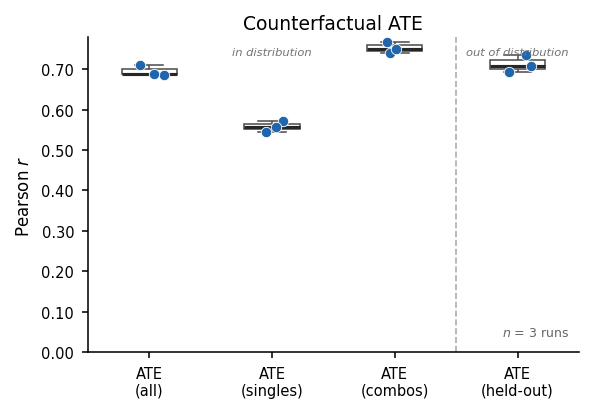

Panel A saved.


In [165]:
# ── Panel A: Counterfactual ATE — in-distribution and OOD ────────────────
METRIC_LABELS = {
    'ate_all':    'ATE\n(all)',
    'ate_single': 'ATE\n(singles)',
    'ate_combo':  'ATE\n(combos)',
    'ate_held':   'ATE\n(held-out)',
}

df_long = runs_df.melt(
    id_vars='run',
    value_vars=list(METRIC_LABELS),
    var_name='metric', value_name='Pearson r',
)
df_long['Metric'] = pd.Categorical(
    df_long['metric'].map(METRIC_LABELS),
    categories=[METRIC_LABELS[k] for k in METRIC_LABELS],
    ordered=True,
)

fig_a, ax_a = plt.subplots(figsize=(4.0, 2.8))

sns.stripplot(
    data=df_long, x='Metric', y='Pearson r',
    color=CLR_SHERLOCK, size=5, jitter=0.15,
    linewidth=0.4, edgecolor='white', ax=ax_a,
)
sns.boxplot(
    data=df_long, x='Metric', y='Pearson r',
    color='white', width=0.45, linewidth=0.75,
    fliersize=0, ax=ax_a,
    boxprops=dict(edgecolor='0.3'),
    whiskerprops=dict(color='0.3'),
    capprops=dict(color='0.3'),
    medianprops=dict(color='0.15', linewidth=1.5),
)

ax_a.axvline(2.5, color='0.55', linewidth=0.8, linestyle='--', alpha=0.7)
ax_a.set_ylim(bottom=0)
_ylim = ax_a.get_ylim()
_y_ann = _ylim[1] - 0.03 * (_ylim[1] - _ylim[0])
ax_a.text(1.0, _y_ann, 'in distribution', ha='center', va='top',
          fontsize=5.5, color='0.45', style='italic')
ax_a.text(3.0, _y_ann, 'out of distribution', ha='center', va='top',
          fontsize=5.5, color='0.45', style='italic')

ax_a.set_xlabel('')
ax_a.set_ylabel('Pearson $r$')
ax_a.set_title('Counterfactual ATE', pad=4)
ax_a.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_a.text(0.98, 0.04, f'$n$ = {N_RUNS} runs',
          transform=ax_a.transAxes, ha='right', va='bottom',
          fontsize=6, color='0.4')

plt.tight_layout()
fig_a.savefig(OUT_DIR / 'panel_a_ate.png', bbox_inches='tight', dpi=300)
plt.show()
print('Panel A saved.')


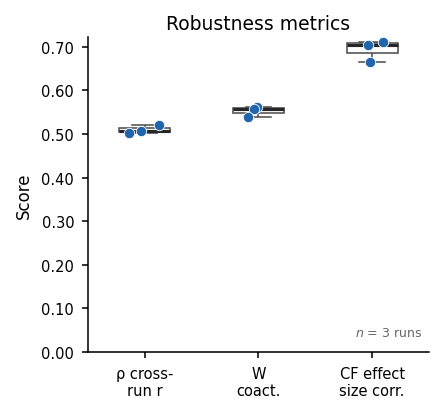

Panel B (robustness) saved.


In [166]:
# ── Panel B: Reproducibility / robustness metrics across N runs ───────────
ROBUST_LABELS = {
    'rho_cross_r':   'ρ cross-\nrun r',
    'w_coact':       'W\ncoact.',
    'effect_size_r': 'CF effect\nsize corr.',
}

df_robust = runs_df.melt(
    id_vars='run',
    value_vars=list(ROBUST_LABELS),
    var_name='metric', value_name='Score',
)
df_robust['Metric'] = pd.Categorical(
    df_robust['metric'].map(ROBUST_LABELS),
    categories=[ROBUST_LABELS[k] for k in ROBUST_LABELS],
    ordered=True,
)

fig_b2, ax_b2 = plt.subplots(figsize=(3.0, 2.8))

sns.stripplot(
    data=df_robust, x='Metric', y='Score',
    color=CLR_SHERLOCK, size=5, jitter=0.15,
    linewidth=0.4, edgecolor='white', ax=ax_b2,
)
sns.boxplot(
    data=df_robust, x='Metric', y='Score',
    color='white', width=0.45, linewidth=0.75,
    fliersize=0, ax=ax_b2,
    boxprops=dict(edgecolor='0.3'),
    whiskerprops=dict(color='0.3'),
    capprops=dict(color='0.3'),
    medianprops=dict(color='0.15', linewidth=1.5),
)

ax_b2.set_ylim(bottom=0)
ax_b2.set_xlabel('')
ax_b2.set_ylabel('Score')
ax_b2.set_title('Robustness metrics', pad=4)
ax_b2.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_b2.text(0.98, 0.04, f'$n$ = {N_RUNS} runs',
           transform=ax_b2.transAxes, ha='right', va='bottom',
           fontsize=6, color='0.4')

plt.tight_layout()
fig_b2.savefig(OUT_DIR / 'panel_b_robustness.png', bbox_inches='tight', dpi=300)
plt.show()
print('Panel B (robustness) saved.')


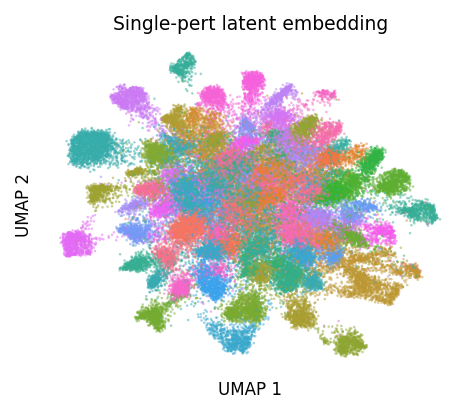

Panel B saved.


In [167]:
# ── Panel B: Single-perturbation latent UMAP ─────────────────────────────
umap_df = pd.DataFrame({
    'UMAP1': sub.obsm['X_umap'][:, 0],
    'UMAP2': sub.obsm['X_umap'][:, 1],
    'pert':  sub.obs[p_key].values,
})

pert_list   = sorted(umap_df['pert'].unique())
_pal        = sns.color_palette('husl', len(pert_list))
pert_colors = dict(zip(pert_list, _pal))

fig_b, ax_b = plt.subplots(figsize=(3.2, 2.8))
ax_b.scatter(
    umap_df['UMAP1'], umap_df['UMAP2'],
    c=[pert_colors[p] for p in umap_df['pert']],
    s=1.5, alpha=0.5, linewidths=0, rasterized=True,
)
ax_b.set_xlabel('UMAP 1')
ax_b.set_ylabel('UMAP 2')
ax_b.set_title('Single-pert latent embedding', pad=4)
ax_b.set_xticks([])
ax_b.set_yticks([])
for sp in ax_b.spines.values():
    sp.set_visible(False)

plt.tight_layout()
fig_b.savefig(OUT_DIR / 'panel_b_umap.png', bbox_inches='tight', dpi=300)
plt.show()
print('Panel B saved.')


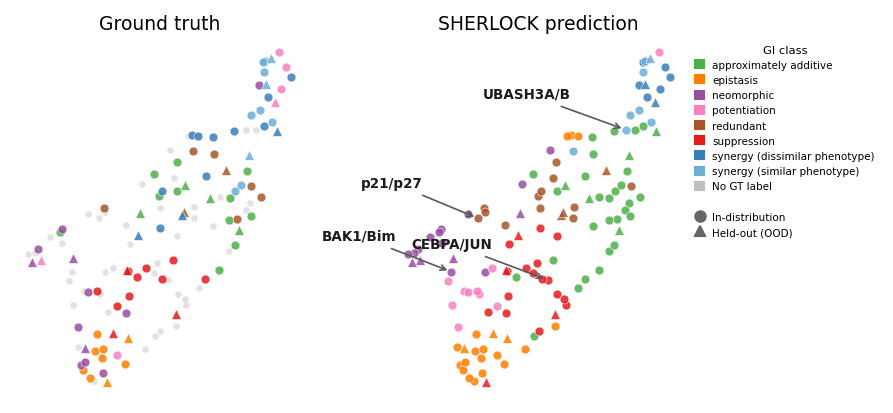

Panel D (synergy UMAP) saved.


In [168]:
# ── Panel D: Synergy UMAP — GT class (left) vs predicted class (right) ──
def _draw_synergy_umap(ax, umap_df, colour_col, title,
                       val_combos=None, arrow_pairs=None, show_unlabelled=False):
    """
    colour_col: column to colour by (gt_gi or predicted_gi).
    show_unlabelled: if True, draw NaN rows as gray (for GT panel only).
    arrow_pairs: {display_label: canonical_idx}
    """
    labelled   = umap_df[umap_df[colour_col].notna()].copy()
    unlabelled = umap_df[umap_df[colour_col].isna()].copy()

    if show_unlabelled and len(unlabelled) > 0:
        ax.scatter(
            unlabelled['UMAP1'], unlabelled['UMAP2'],
            color='0.75', s=10, alpha=0.45, linewidths=0, zorder=1,
        )

    if val_combos is not None:
        in_dist  = labelled[~labelled.index.isin(val_combos)]
        out_dist = labelled[labelled.index.isin(val_combos)]
    else:
        in_dist  = labelled
        out_dist = labelled.iloc[0:0]

    for cls in sorted(labelled[colour_col].unique()):
        color   = PALETTE_GI.get(str(cls), '#888888')
        grp_id  = in_dist[in_dist[colour_col] == cls]
        grp_ood = out_dist[out_dist[colour_col] == cls]
        if len(grp_id) > 0:
            ax.scatter(
                grp_id['UMAP1'], grp_id['UMAP2'],
                color=color, marker='o', s=18, alpha=0.85,
                linewidths=0.3, edgecolors='white', zorder=2,
            )
        if len(grp_ood) > 0:
            ax.scatter(
                grp_ood['UMAP1'], grp_ood['UMAP2'],
                color=color, marker='^', s=22, alpha=0.85,
                linewidths=0.3, edgecolors='white', zorder=3,
            )

    if arrow_pairs:
        for display_label, idx in arrow_pairs.items():
            if idx not in umap_df.index:
                continue
            row  = umap_df.loc[idx]
            x, y = float(row['UMAP1']), float(row['UMAP2'])
            ax.annotate(
                display_label,
                xy=(x, y), xytext=(x - 1.5, y + 0.8),
                fontsize=6.5, fontweight='bold', color='0.1',
                ha='right', va='bottom',
                arrowprops=dict(
                    arrowstyle='->', color='0.35',
                    lw=0.8, shrinkA=2, shrinkB=2,
                ),
            )

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(title, pad=3)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)


fig_d, axes_d = plt.subplots(1, 2, figsize=(6.0, 2.8))

_draw_synergy_umap(axes_d[0], syn_umap, 'gt_gi', 'Ground truth',
                   val_combos=val_combos, arrow_pairs=None,
                   show_unlabelled=True)
_draw_synergy_umap(axes_d[1], syn_umap, 'predicted_gi', 'SHERLOCK prediction',
                   val_combos=val_combos, arrow_pairs=novel_arrow_pairs,
                   show_unlabelled=False)

# Legend
class_handles = [Patch(color=PALETTE_GI.get(cls, '#888888'), label=cls) for cls in sorted(PALETTE_GI)]
extra_handles = [
    Patch(color='0.75', label='No GT label'),
    Patch(color='none', label=''),
    Line2D([0], [0], marker='o', color='0.4', linestyle='None', ms=5, label='In-distribution'),
    Line2D([0], [0], marker='^', color='0.4', linestyle='None', ms=5, label='Held-out (OOD)'),
]
axes_d[1].legend(
    handles=class_handles + extra_handles,
    title='GI class', frameon=False,
    fontsize=5, title_fontsize=5.5,
    bbox_to_anchor=(1.01, 1), loc='upper left',
    handlelength=0.8, handleheight=0.8,
)

plt.tight_layout()
fig_d.savefig(OUT_DIR / 'panel_d_synergy_umap.png', bbox_inches='tight', dpi=300)
plt.show()
print('Panel D (synergy UMAP) saved.')


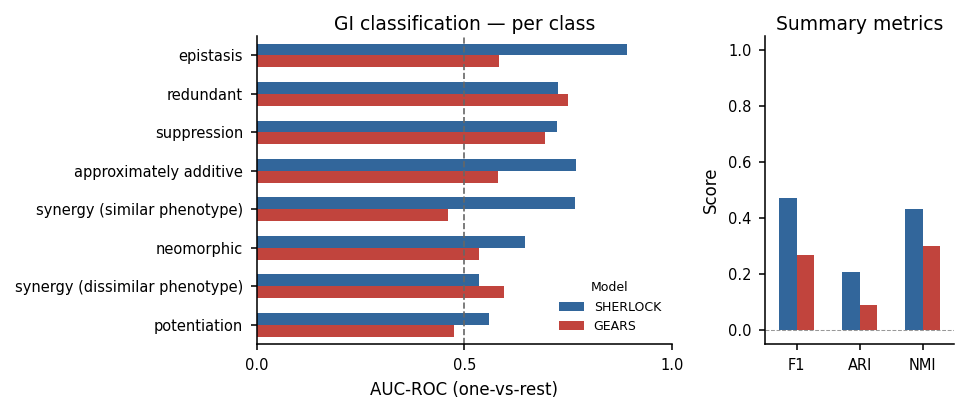

Panel E saved.


In [169]:
# ── Panel E: GI classification — per-class AUC (left) + summary (right) ──
class_order = (
    class_df.groupby('class')['auc_roc']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
bar_pal = {'SHERLOCK': CLR_SHERLOCK, 'GEARS': CLR_GEARS}

fig_e, (ax_e1, ax_e2) = plt.subplots(
    1, 2, figsize=(6.5, 2.8),
    gridspec_kw={'width_ratios': [2.2, 1]},
)

# Left: per-class AUC-ROC
sns.barplot(
    data=class_df.dropna(subset=['auc_roc']),
    y='class', x='auc_roc',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    palette=bar_pal, order=class_order,
    width=0.62, ax=ax_e1,
)
ax_e1.axvline(0.5, color='0.4', linewidth=0.8, linestyle='--')
ax_e1.set_xlabel('AUC-ROC (one-vs-rest)')
ax_e1.set_ylabel('')
ax_e1.set_title('GI classification — per class', pad=3)
ax_e1.set_xlim(0, 1)
ax_e1.set_xticks([0, 0.5, 1.0])
ax_e1.spines['top'].set_visible(False)
ax_e1.spines['right'].set_visible(False)
h1, l1 = ax_e1.get_legend_handles_labels()
ax_e1.legend(h1, l1, title='Model', frameon=False, fontsize=6, title_fontsize=6,
             loc='lower right')

# Right: F1, ARI, NMI (silhouette removed — shown on UMAP panel instead)
SUMM_METRICS = {
    'f1_weighted': 'F1',
    'ari':         'ARI',
    'nmi':         'NMI',
}
summ_long = summary_df[['model'] + list(SUMM_METRICS)].melt(
    id_vars='model', value_vars=list(SUMM_METRICS),
    var_name='metric', value_name='score',
)
summ_long['Metric'] = pd.Categorical(
    summ_long['metric'].map(SUMM_METRICS),
    categories=list(SUMM_METRICS.values()), ordered=True,
)

sns.barplot(
    data=summ_long, x='Metric', y='score',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    palette=bar_pal, width=0.55, ax=ax_e2,
)
ax_e2.axhline(0, color='0.6', linewidth=0.5, linestyle='--')
ax_e2.set_xlabel('')
ax_e2.set_ylabel('Score')
ax_e2.set_title('Summary metrics', pad=3)
ax_e2.set_ylim(-0.05, 1.05)
ax_e2.spines['top'].set_visible(False)
ax_e2.spines['right'].set_visible(False)
ax_e2.get_legend().remove()

plt.tight_layout()
fig_e.savefig(OUT_DIR / 'panel_e_gi_classification.png', bbox_inches='tight', dpi=300)
plt.show()
print('Panel E saved.')


Main figure saved to results/norman_figure/main_figure.png


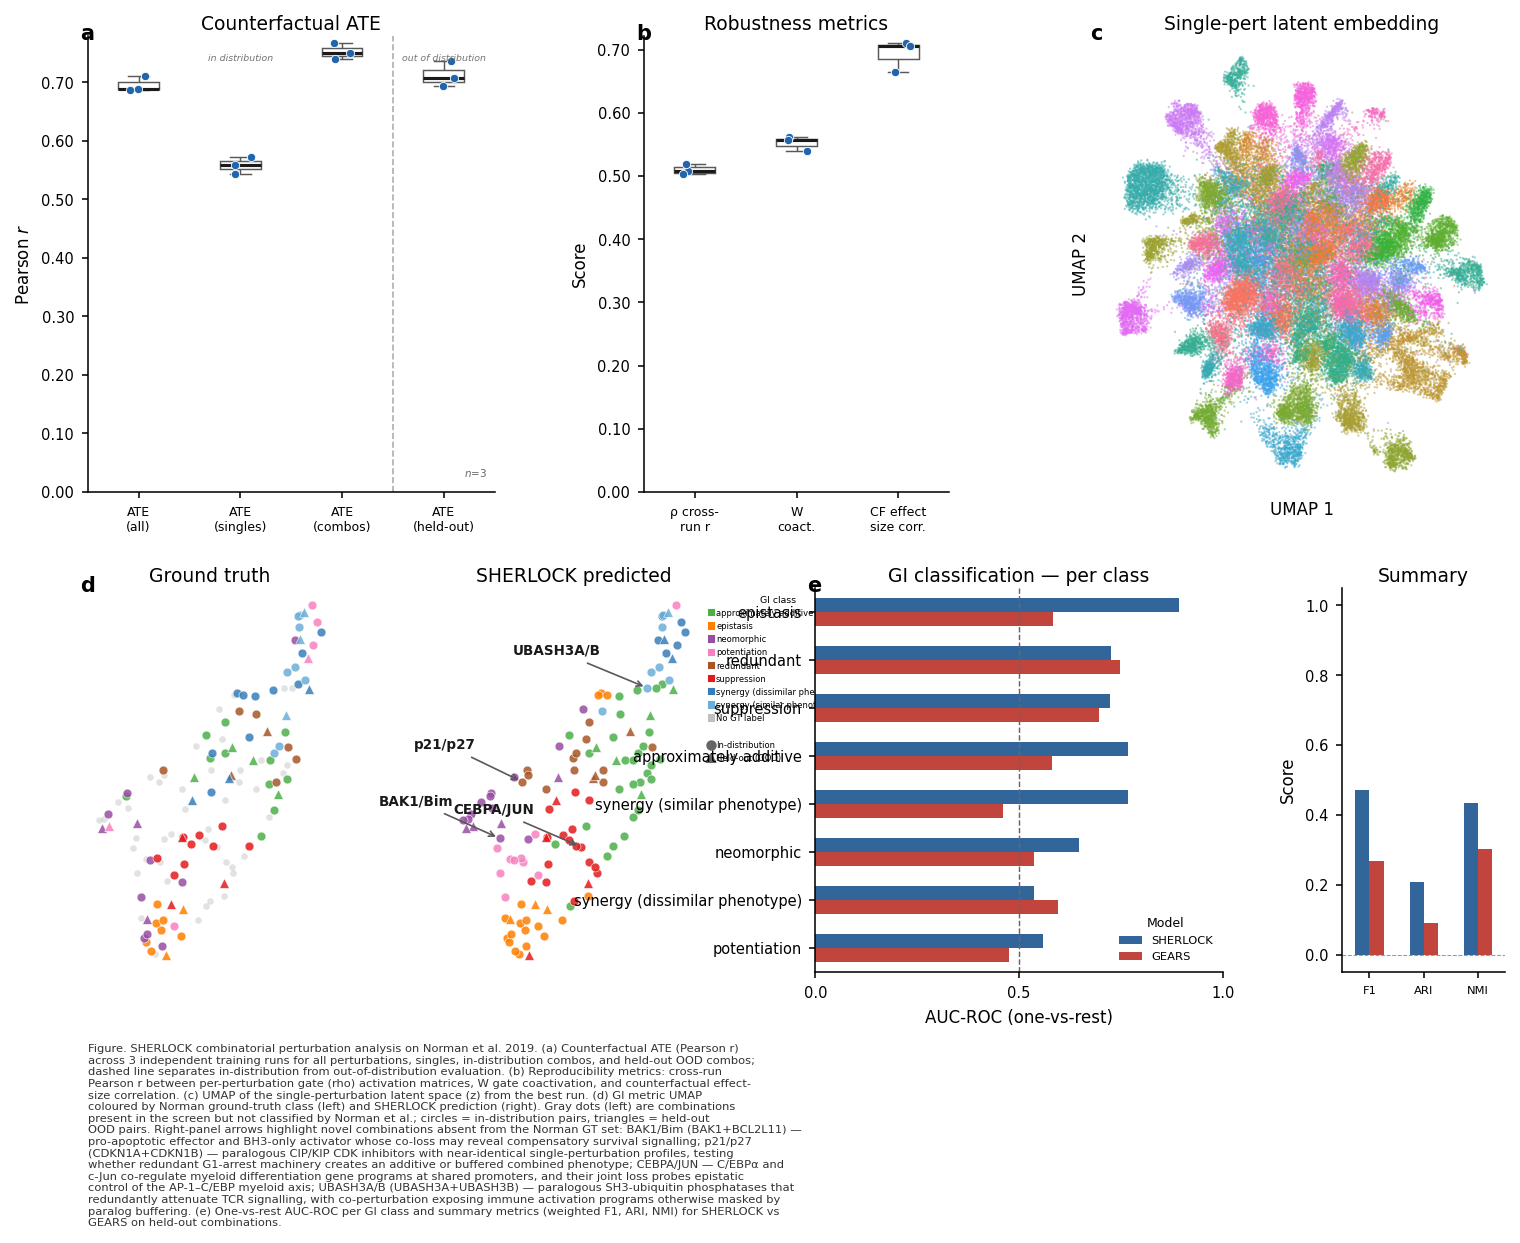

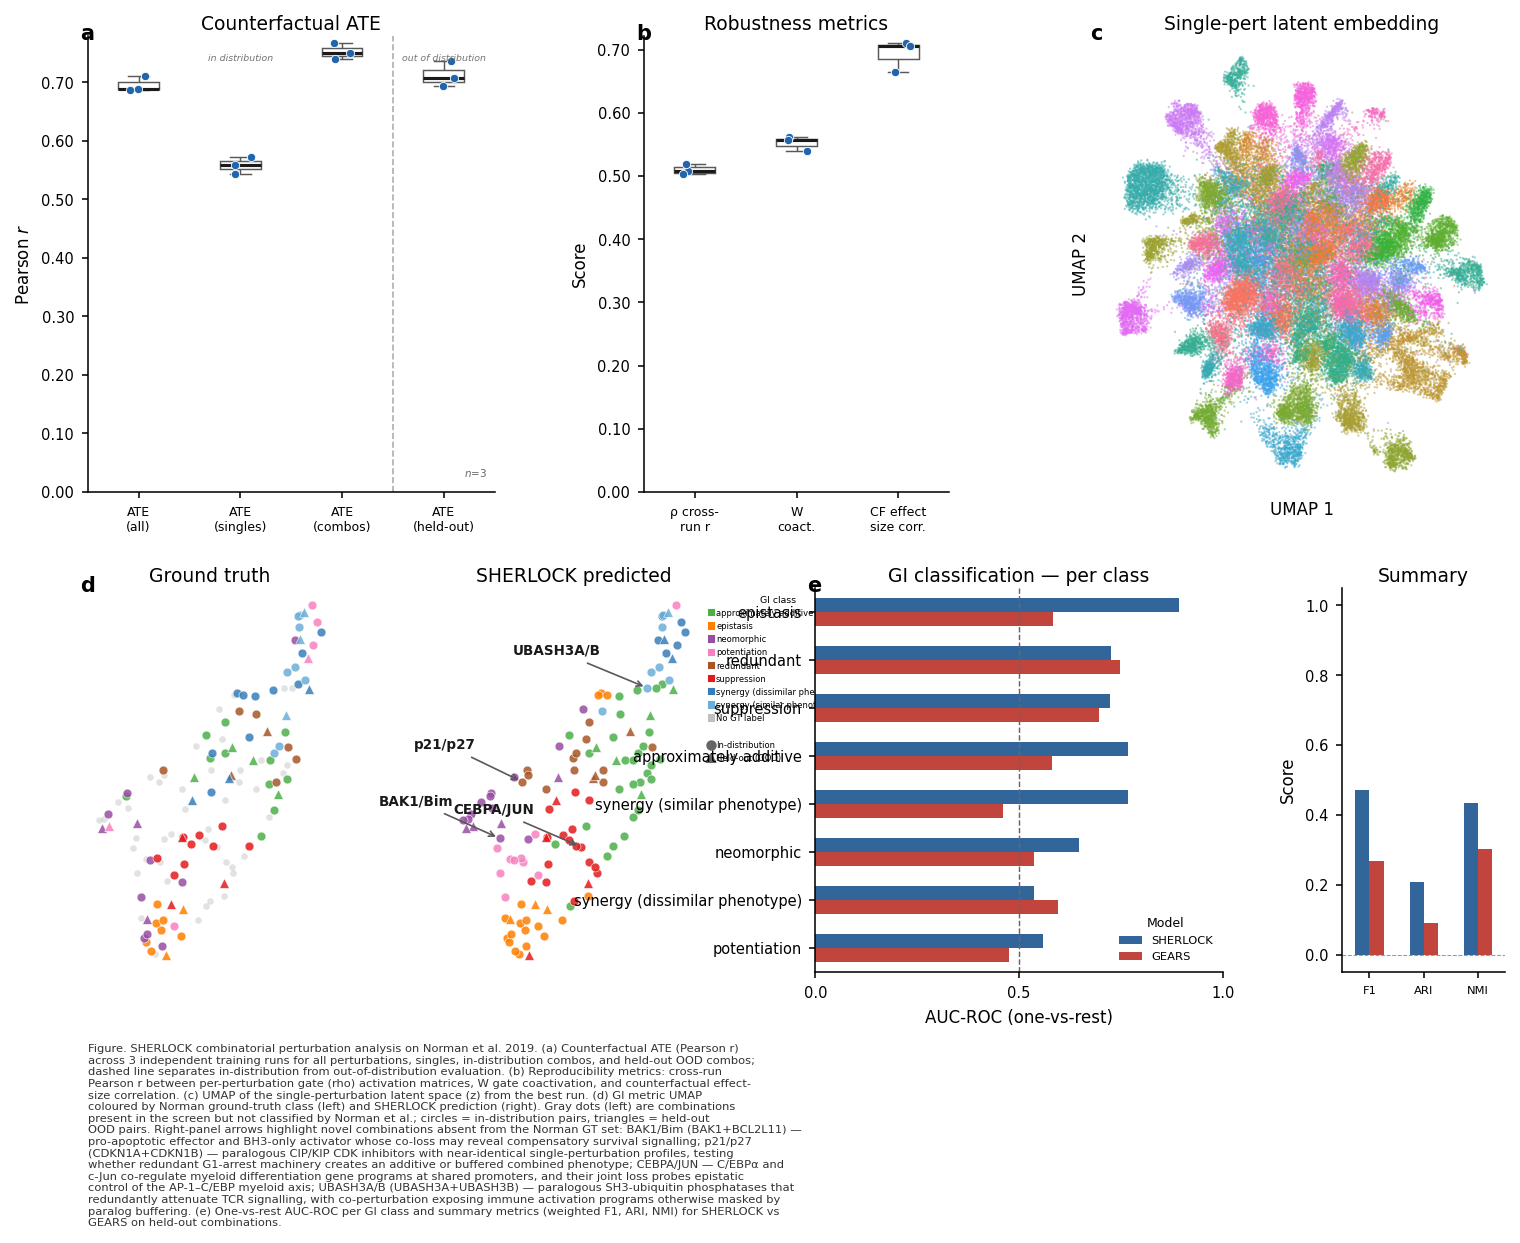

In [170]:
# ── Composite main figure — 5 panels ─────────────────────────────────────
FIG_W, FIG_H = 10.5, 8.0
LABEL_KW = dict(fontsize=10, fontweight='bold', va='top', ha='left')

plt.close('all')
fig = plt.figure(figsize=(FIG_W, FIG_H))

gs_top = fig.add_gridspec(
    1, 3, width_ratios=[4, 3, 4],
    left=0.07, right=0.97, top=0.94, bottom=0.56,
    wspace=0.40,
)
gs_bot = fig.add_gridspec(
    1, 4, width_ratios=[3, 3, 5, 2],
    left=0.07, right=0.97, top=0.48, bottom=0.16,
    wspace=0.45,
)

ax_a    = fig.add_subplot(gs_top[0, 0])
ax_b    = fig.add_subplot(gs_top[0, 1])
ax_c    = fig.add_subplot(gs_top[0, 2])
ax_d_gt = fig.add_subplot(gs_bot[0, 0])
ax_d_pd = fig.add_subplot(gs_bot[0, 1])
ax_e1   = fig.add_subplot(gs_bot[0, 2])
ax_e2   = fig.add_subplot(gs_bot[0, 3])

# ── (a) Counterfactual ATE ────────────────────────────────────────────────
sns.stripplot(data=df_long, x='Metric', y='Pearson r',
    color=CLR_SHERLOCK, size=4, jitter=0.12,
    linewidth=0.4, edgecolor='white', ax=ax_a)
sns.boxplot(data=df_long, x='Metric', y='Pearson r',
    color='white', width=0.40, linewidth=0.7, fliersize=0, ax=ax_a,
    boxprops=dict(edgecolor='0.35'), whiskerprops=dict(color='0.35'),
    capprops=dict(color='0.35'), medianprops=dict(color='0.1', linewidth=1.5))
ax_a.axvline(2.5, color='0.55', linewidth=0.8, linestyle='--', alpha=0.7)
ax_a.set_ylim(bottom=0)
_yl = ax_a.get_ylim()
_ya = _yl[1] - 0.04 * (_yl[1] - _yl[0])
ax_a.text(1.0, _ya, 'in distribution', ha='center', va='top',
    fontsize=4.5, color='0.45', style='italic')
ax_a.text(3.0, _ya, 'out of distribution', ha='center', va='top',
    fontsize=4.5, color='0.45', style='italic')
ax_a.set_xlabel(''); ax_a.set_ylabel('Pearson $r$')
ax_a.set_title('Counterfactual ATE', pad=3)
ax_a.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_a.tick_params(axis='x', labelsize=6)
ax_a.text(0.98, 0.03, f'$n$={N_RUNS}',
    transform=ax_a.transAxes, ha='right', va='bottom', fontsize=5, color='0.4')
ax_a.spines['top'].set_visible(False); ax_a.spines['right'].set_visible(False)

# ── (b) Robustness metrics ────────────────────────────────────────────────
sns.stripplot(data=df_robust, x='Metric', y='Score',
    color=CLR_SHERLOCK, size=4, jitter=0.12,
    linewidth=0.4, edgecolor='white', ax=ax_b)
sns.boxplot(data=df_robust, x='Metric', y='Score',
    color='white', width=0.40, linewidth=0.7, fliersize=0, ax=ax_b,
    boxprops=dict(edgecolor='0.35'), whiskerprops=dict(color='0.35'),
    capprops=dict(color='0.35'), medianprops=dict(color='0.1', linewidth=1.5))
ax_b.set_ylim(bottom=0)
ax_b.set_xlabel(''); ax_b.set_ylabel('Score')
ax_b.set_title('Robustness metrics', pad=3)
ax_b.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_b.tick_params(axis='x', labelsize=6)
ax_b.spines['top'].set_visible(False); ax_b.spines['right'].set_visible(False)

# ── (c) Single-pert latent UMAP ───────────────────────────────────────────
ax_c.scatter(umap_df['UMAP1'], umap_df['UMAP2'],
    c=[pert_colors[p] for p in umap_df['pert']],
    s=1.2, alpha=0.5, linewidths=0, rasterized=True)
ax_c.set_xlabel('UMAP 1'); ax_c.set_ylabel('UMAP 2')
ax_c.set_title('Single-pert latent embedding', pad=3)
ax_c.set_xticks([]); ax_c.set_yticks([])
for sp in ax_c.spines.values(): sp.set_visible(False)

# ── (d) Synergy UMAPs ─────────────────────────────────────────────────────
# GT: no arrows, gray = unlabelled in Norman et al.
# Predicted: arrows to biologically interesting novel (unlabelled) combinations
_draw_synergy_umap(ax_d_gt, syn_umap, 'gt_gi', 'Ground truth',
                   val_combos=val_combos, arrow_pairs=None,
                   show_unlabelled=True)
_draw_synergy_umap(ax_d_pd, syn_umap, 'predicted_gi', 'SHERLOCK predicted',
                   val_combos=val_combos, arrow_pairs=novel_arrow_pairs,
                   show_unlabelled=False)

gi_handles = [Patch(color=PALETTE_GI.get(cls, '#888888'), label=cls) for cls in sorted(PALETTE_GI)]
extra_handles = [
    Patch(color='0.75', label='No GT label'),
    Patch(color='none', label=''),
    Line2D([0], [0], marker='o', color='0.4', linestyle='None', ms=4, label='In-distribution'),
    Line2D([0], [0], marker='^', color='0.4', linestyle='None', ms=4, label='Held-out (OOD)'),
]
ax_d_pd.legend(
    handles=gi_handles + extra_handles,
    title='GI class', frameon=False,
    fontsize=4, title_fontsize=4.5,
    bbox_to_anchor=(1.02, 1), loc='upper left',
    handlelength=0.6, handleheight=0.6, handletextpad=0.3,
)

# ── (e-left) Per-class AUC-ROC ────────────────────────────────────────────
sns.barplot(data=class_df.dropna(subset=['auc_roc']),
    y='class', x='auc_roc',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    palette=bar_pal, order=class_order, width=0.60, ax=ax_e1)
ax_e1.axvline(0.5, color='0.4', linewidth=0.7, linestyle='--')
ax_e1.set_xlabel('AUC-ROC (one-vs-rest)'); ax_e1.set_ylabel('')
ax_e1.set_title('GI classification — per class', pad=3)
ax_e1.set_xlim(0, 1); ax_e1.set_xticks([0, 0.5, 1.0])
ax_e1.spines['top'].set_visible(False); ax_e1.spines['right'].set_visible(False)
h1, l1 = ax_e1.get_legend_handles_labels()
ax_e1.legend(h1, l1, title='Model', frameon=False,
    fontsize=5.5, title_fontsize=6, loc='lower right')

# ── (e-right) Summary metrics — F1, ARI, NMI ─────────────────────────────
sns.barplot(data=summ_long, x='Metric', y='score',
    hue='model', hue_order=['SHERLOCK', 'GEARS'],
    palette=bar_pal, width=0.52, ax=ax_e2)
ax_e2.axhline(0, color='0.6', linewidth=0.5, linestyle='--')
ax_e2.set_xlabel(''); ax_e2.set_ylabel('Score')
ax_e2.set_title('Summary', pad=3)
ax_e2.set_ylim(-0.05, 1.05)
ax_e2.spines['top'].set_visible(False); ax_e2.spines['right'].set_visible(False)
ax_e2.tick_params(axis='x', labelsize=5.5)
ax_e2.get_legend().remove()

# ── Subfigure labels ──────────────────────────────────────────────────────
def _pos(gs_obj, row, col):
    bbox = gs_obj[row, col].get_position(fig)
    return bbox.x0 - 0.005, bbox.y1 + 0.010

for lbl, (x, y) in {
    'a': _pos(gs_top, 0, 0),
    'b': _pos(gs_top, 0, 1),
    'c': _pos(gs_top, 0, 2),
    'd': _pos(gs_bot, 0, 0),
    'e': _pos(gs_bot, 0, 2),
}.items():
    fig.text(x, y, lbl, **LABEL_KW)

# ── Figure caption ────────────────────────────────────────────────────────
_caption_raw = (
    "Figure. SHERLOCK combinatorial perturbation analysis on Norman et al. 2019. "
    "(a) Counterfactual ATE (Pearson r) across {n} independent training runs for all "
    "perturbations, singles, in-distribution combos, and held-out OOD combos; dashed line "
    "separates in-distribution from out-of-distribution evaluation. "
    "(b) Reproducibility metrics: cross-run Pearson r between per-perturbation gate (rho) "
    "activation matrices, W gate coactivation, and counterfactual effect-size correlation. "
    "(c) UMAP of the single-perturbation latent space (z) from the best run. "
    "(d) GI metric UMAP coloured by Norman ground-truth class (left) and SHERLOCK prediction "
    "(right). Gray dots (left) are combinations present in the screen but not classified by "
    "Norman et al.; circles = in-distribution pairs, triangles = held-out OOD pairs. "
    "Right-panel arrows highlight novel combinations absent from the Norman GT set: "
    "BAK1/Bim (BAK1+BCL2L11) — pro-apoptotic effector and BH3-only activator whose co-loss "
    "may reveal compensatory survival signalling; "
    "p21/p27 (CDKN1A+CDKN1B) — paralogous CIP/KIP CDK inhibitors with near-identical "
    "single-perturbation profiles, testing whether redundant G1-arrest machinery creates an "
    "additive or buffered combined phenotype; "
    "CEBPA/JUN — C/EBPα and c-Jun co-regulate myeloid differentiation gene programs at shared "
    "promoters, and their joint loss probes epistatic control of the AP-1–C/EBP myeloid axis; "
    "UBASH3A/B (UBASH3A+UBASH3B) — paralogous SH3-ubiquitin phosphatases that redundantly "
    "attenuate TCR signalling, with co-perturbation exposing immune activation programs "
    "otherwise masked by paralog buffering. "
    "(e) One-vs-rest AUC-ROC per GI class and summary metrics "
    "(weighted F1, ARI, NMI) for SHERLOCK vs GEARS on held-out combinations."
).format(n=N_RUNS)

fig.text(
    0.07, 0.10,
    textwrap.fill(_caption_raw, width=115),
    ha='left', va='top', fontsize=5.5, color='0.2',
    transform=fig.transFigure,
)

fig.savefig(OUT_DIR / 'main_figure.png', bbox_inches='tight', dpi=300)
print(f'Main figure saved to {OUT_DIR}/main_figure.png')
fig


In [171]:
# ── Summary statistics ────────────────────────────────────────────────────
print('=== ATE across runs ===')
print(runs_df[['run', 'ate_all', 'ate_single', 'ate_combo', 'ate_held']].to_string(index=False))

print(f'\nMean ± SD:')
for col in ['ate_all', 'ate_single', 'ate_combo', 'ate_held']:
    print(f"  {col:15s}  {runs_df[col].mean():.4f} ± {runs_df[col].std():.4f}")

print('\n=== GI classification summary (SHERLOCK vs GEARS) ===')
print(summary_df[['model', 'f1_weighted', 'silhouette', 'ari', 'nmi']].to_string(index=False))

=== ATE across runs ===
 run  ate_all  ate_single  ate_combo  ate_held
   1 0.687140    0.572785   0.740377  0.693406
   2 0.710575    0.558373   0.767982  0.736607
   3 0.688989    0.544178   0.750078  0.707117

Mean ± SD:
  ate_all          0.6956 ± 0.0130
  ate_single       0.5584 ± 0.0143
  ate_combo        0.7528 ± 0.0140
  ate_held         0.7124 ± 0.0221

=== GI classification summary (SHERLOCK vs GEARS) ===
   model  f1_weighted  silhouette      ari      nmi
SHERLOCK     0.471029   -0.002543 0.207916 0.434162
   GEARS     0.268394   -0.118093 0.090610 0.301848
